C:\Users\a1231060\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


0.5787297250460844


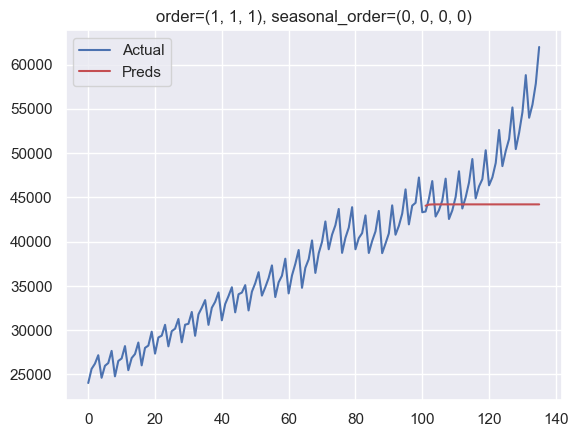

In [29]:
from statsmodels.datasets import get_rdataset
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error as mape
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Get data
uk = get_rdataset('UKNonDurables', 'AER')
uk = uk.data
uk_pre1980 = uk[uk.time <= 1980]
# print(uk_pre1980)
# Make ARIMA model
# order: p : autoregressive order. d : difference order. q : moving average order
# trend: trend inputs are 'c' (constant), 't' (linear trend in time), 
#    'ct' (both), 'ctt' (both with trend squared) or an interable defining a polynomial, 
#  e.g., [1, 1, 0, 1] is `a + b*t + ct**3`
#   BUT: if you include trend, the d must be 0 (d will eliminate trend, so does not make sense)
order = (1, 1, 1)
# Without a seasonal component
seasonal_order = (0, 0, 0, 0)
arima = ARIMA(uk_pre1980.value, 
            order=order, 
            seasonal_order=seasonal_order, 
            trend='n')
res = arima.fit()
# Plot
all_elements = len(uk) - len(uk_pre1980)
MAPE = mape(uk_pre1980.value[:all_elements], res.forecast(steps=all_elements))
print(MAPE)

plt.plot(uk.value, 'b', label='Actual')
plt.plot(res.forecast(steps=all_elements), 'r', label='Preds')
plt.title(f'order={order}, seasonal_order={seasonal_order}')
plt.legend()
plt.show()